# D2.1: Fix Memorisation — Overfit 1 Trajectory

**Goal:** Address the blockers D2 surfaced — the model couldn't memorise 17 chunks (L2=910, target <0.1).

**Changes from D2 (see `results/2026-03-10/D2.1_memorisation_fixes.md`):**

| Parameter | D2 (failed) | D2.1 |
|-----------|-------------|------|
| dim_mults | (1, 2) ~250k params | **(1, 4, 8)** ~2M+ params |
| frame_stack | 2 | **1** (match SOPE) |
| chunk_size | 8 | **7** (total_horizon=8, divisible by 4) |
| sample() shape bug | present | **fixed** in source |
| predict_epsilon | True only | **test both True and False** |

**Also fixed:** Off-by-one in `SopeDiffuser.sample()` — sampling generated sequences 1 timestep
shorter than training. Fixed to use `total_chunk_horizon`. (Didn't affect D2's chunk eval which
bypassed `sample()`, but would have affected any code calling it directly.)

**Success criteria:** Chunk L2 < 1.0 (memorisation). Target < 0.1 (near-perfect).

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import h5py
import torch

REPO_ROOT = Path("../../").resolve()
sys.path.insert(0, str(REPO_ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Repo root: {REPO_ROOT}")

# --- Common paths ---
POLICY_DIR = REPO_ROOT / "third_party" / "robomimic" / "diffusion_policy_trained_models" / "test"
policy_train_dirs = sorted([d for d in POLICY_DIR.glob("*") if d.is_dir()])
assert len(policy_train_dirs) > 0, "No trained policies found."
policy_train_dir = policy_train_dirs[-1]
print(f"Using policy from: {policy_train_dir}")

# --- Hyperparams (tuned for memorization) ---
N_ROLLOUTS = 1        # Single trajectory
EPOCHS = 2000         # Many passes over ~17 chunks
HORIZON = 60
gamma = 1.0
BATCH_SIZE = 64       # Larger than dataset → sees all chunks every step
NUM_TRAJS = 1         # Generate 1 synthetic trajectory to compare
LR = 1e-3             # High LR for fast memorization (no scheduler)

CHECKPOINT_EPOCHS = [100, 500, 1000, 2000]

# --- D2.1 changes ---
FRAME_STACK = 1       # Down from 2 — match SOPE
CHUNK_SIZE = 7        # Down from 8 — total_horizon=8, divisible by 4 for dim_mults=(1,4,8)
DIM_MULTS = (1, 4, 8) # Up from (1,2) — match SOPE capacity

# --- Quaternion removal config (same as D1) ---
KEEP_INDICES = [0, 1, 2, 7, 8, 9, 10, 11, 12, 17, 18]
REDUCED_STATE_DIM = len(KEEP_INDICES)  # 11

DIM_LABELS = [
    "obj_px", "obj_py", "obj_pz",
    "g2c_x", "g2c_y", "g2c_z",
    "eef_px", "eef_py", "eef_pz",
    "grip_0", "grip_1",
]

CUBE_Z_IDX = 2
EEF_Z_IDX = 8
CUBE_X_IDX = 0
EEF_X_IDX = 6
SUCCESS_THRESHOLD = 0.84

print(f"D2.1 overfit sanity check: {N_ROLLOUTS} rollout, {EPOCHS} epochs, LR={LR}, no scheduler")
print(f"State dim: {REDUCED_STATE_DIM} (no quaternions)")
print(f"frame_stack={FRAME_STACK}, chunk_size={CHUNK_SIZE}, total_horizon={FRAME_STACK+CHUNK_SIZE}")
print(f"dim_mults={DIM_MULTS}")

Device: cuda
Repo root: /home1/reishuen/latent_sope
Using policy from: /home1/reishuen/latent_sope/third_party/robomimic/diffusion_policy_trained_models/test/20260309132349
D2.1 overfit sanity check: 1 rollout, 2000 epochs, LR=0.001, no scheduler
State dim: 11 (no quaternions)
frame_stack=1, chunk_size=7, total_horizon=8
dim_mults=(1, 4, 8)


## Step 0: Oracle (cached, unchanged)

In [2]:
from src.latent_sope.eval.oracle import load_oracle_result

oracle_path = policy_train_dir / "oracle_50.json"
assert oracle_path.exists()

oracle_result = load_oracle_result(oracle_path)
oracle_value = oracle_result.mean_return
print(f"Oracle V^pi = {oracle_value:.3f} (std={np.std(oracle_result.returns):.3f}, K={oracle_result.num_rollouts})")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.embedding

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Oracle V^pi = 0.540 (std=0.498, K=50)


## Step 1: Load 1 Rollout & Strip Quaternions

In [3]:
from src.latent_sope.robomimic_interface.rollout import load_rollout_latents

# Use the filtered no-quat rollouts if they exist, otherwise create from originals
filtered_dir = policy_train_dir / "rollout_latents_50_no_quat"
original_dir = policy_train_dir / "rollout_latents_50"

if filtered_dir.exists() and len(list(filtered_dir.glob("*.h5"))) >= 1:
    # Reuse from D1 run
    rollout_paths = [sorted(filtered_dir.glob("*.h5"))[0]]
    print(f"Using pre-filtered rollout: {rollout_paths[0].name}")
else:
    # Create filtered version of first rollout
    filtered_dir.mkdir(exist_ok=True)
    src_path = sorted(original_dir.glob("*.h5"))[0]
    dst_path = filtered_dir / src_path.name

    with h5py.File(str(src_path), "r") as f_in:
        latents_full = np.asarray(f_in["latents"], dtype=np.float32)
        actions = np.asarray(f_in["actions"], dtype=np.float32)
        rewards = np.asarray(f_in["rewards"], dtype=np.float32)
        dones = np.asarray(f_in["dones"])
        attrs = dict(f_in.attrs)

    if latents_full.ndim == 3:
        latents_reduced = latents_full[:, :, KEEP_INDICES]
    else:
        latents_reduced = latents_full[:, KEEP_INDICES]

    with h5py.File(str(dst_path), "w") as f_out:
        f_out.create_dataset("latents", data=latents_reduced, compression="gzip")
        f_out.create_dataset("actions", data=actions, compression="gzip")
        f_out.create_dataset("rewards", data=rewards, compression="gzip")
        f_out.create_dataset("dones", data=dones, compression="gzip")
        for k, v in attrs.items():
            f_out.attrs[k] = v

    rollout_paths = [dst_path]
    print(f"Created filtered rollout: {dst_path.name}")

# Verify
sample_traj = load_rollout_latents(rollout_paths[0])
latents_dim = sample_traj.latents.shape[-1]
action_dim = sample_traj.actions.shape[-1]
print(f"Latent shape: {sample_traj.latents.shape}, Action shape: {sample_traj.actions.shape}")
print(f"Latent dim: {latents_dim}, Action dim: {action_dim}")
print(f"Trajectory length: {sample_traj.horizon} steps")
print(f"Total reward: {sample_traj.total_reward}, Success: {sample_traj.success}")

Using pre-filtered rollout: rollout_000.h5
Latent shape: (41, 2, 11), Action shape: (41, 7)
Latent dim: 11, Action dim: 7
Trajectory length: 41 steps
Total reward: 1.0, Success: True


## Step 2: Chunk the Single Trajectory

In [4]:
from src.latent_sope.robomimic_interface.dataset import (
    RolloutChunkDatasetConfig,
    make_rollout_chunk_dataloader,
)

dataset_config = RolloutChunkDatasetConfig(
    chunk_size=CHUNK_SIZE,       # 7 (was 8)
    stride=2,
    frame_stack=FRAME_STACK,     # 1 (was 2)
    source="latents",
    latents_dim=latents_dim,
    action_dim=action_dim,
    normalize=True,
    return_metadata=True,
)

# drop_last=False so we don't lose the only batch!
dataloader, norm_stats = make_rollout_chunk_dataloader(
    paths=rollout_paths,
    config=dataset_config,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)

n_batches = len(dataloader)
n_chunks = len(dataloader.dataset)
print(f"Dataset: {n_chunks} chunks from 1 trajectory")
print(f"DataLoader: {n_batches} batch(es) of up to {BATCH_SIZE}")
print(f"Total gradient steps over {EPOCHS} epochs: {n_batches * EPOCHS}")
print(f"Each chunk seen ~{EPOCHS * BATCH_SIZE / max(n_chunks, 1):.0f} times")
print(f"Normalization stats: mean shape={norm_stats.mean.shape}")

# Verify batch shapes
sample_batch = next(iter(dataloader))
for k, v in sample_batch.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k}: {v.shape}")
    else:
        print(f"  {k}: {type(v)}")

Dataset: 17 chunks from 1 trajectory
DataLoader: 1 batch(es) of up to 64
Total gradient steps over 2000 epochs: 2000
Each chunk seen ~7529 times
Normalization stats: mean shape=(18,)


  states_from: torch.Size([17, 1, 11])
  actions_from: torch.Size([17, 1, 7])
  states_to: torch.Size([17, 8, 11])
  actions_to: torch.Size([17, 7, 7])
  metadata: <class 'dict'>


## Step 3: Train — Test Both predict_epsilon Modes

We run the overfit test twice:
1. **predict_epsilon=True** (noise prediction, our current default, matches SOPE Hopper)
2. **predict_epsilon=False** (x₀ prediction, matches SOPE HalfCheetah)

Both use the larger model (dim_mults=(1,4,8)) and frame_stack=1.

In [5]:
from tqdm.auto import tqdm
from dataclasses import asdict
import matplotlib.pyplot as plt
from src.latent_sope.diffusion.sope_diffuser import (
    SopeDiffusionConfig,
    SopeDiffuser,
    NormalizationStats as DiffusionNormStats,
    cross_validate_configs,
)

diff_norm_stats = None
if norm_stats is not None:
    diff_norm_stats = DiffusionNormStats(mean=norm_stats.mean, std=norm_stats.std)

def make_diffuser_and_optimizer(predict_epsilon: bool):
    """Create a fresh diffuser + optimizer for a given predict_epsilon mode."""
    cfg = SopeDiffusionConfig(
        chunk_horizon=CHUNK_SIZE,          # 7
        frame_stack=FRAME_STACK,           # 1
        state_dim=latents_dim,             # 11
        action_dim=action_dim,             # 7
        diffusion_steps=256,
        dim_mults=DIM_MULTS,               # (1, 4, 8)
        attention=False,
        loss_type="l2",
        action_weight=5.0,
        predict_epsilon=predict_epsilon,
        lr=LR,
        guided=False,
    )
    cross_validate_configs(dataset_config, cfg)
    d = SopeDiffuser(cfg=cfg, normalization_stats=diff_norm_stats, device=device)
    opt = torch.optim.Adam(d.diffusion.parameters(), lr=LR)
    n_params = sum(p.numel() for p in d.diffusion.parameters())
    print(f"  predict_epsilon={predict_epsilon}, total_horizon={cfg.total_chunk_horizon}, params={n_params:,}")
    return d, opt, cfg

print("Initialising both models...")
diffuser_eps, optimizer_eps, cfg_eps = make_diffuser_and_optimizer(predict_epsilon=True)
diffuser_x0, optimizer_x0, cfg_x0 = make_diffuser_and_optimizer(predict_epsilon=False)
print("Done.")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Initialising both models...
[ models/temporal ] Channel dimensions: [(18, 32), (32, 128), (128, 256)]
[(18, 32), (32, 128), (128, 256)]


  predict_epsilon=True, total_horizon=8, params=3,684,818
[ models/temporal ] Channel dimensions: [(18, 32), (32, 128), (128, 256)]
[(18, 32), (32, 128), (128, 256)]
  predict_epsilon=False, total_horizon=8, params=3,684,818
Done.


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


In [6]:
# --- Training loop for both models ---
GRAD_CLIP = 1.0

def train_overfit(diffuser, optimizer, label, epochs=EPOCHS):
    """Train a diffuser on the single-trajectory dataset and return loss history."""
    all_losses = []
    epoch_mean_losses = []
    diffuser.diffusion.train()

    for epoch in range(1, epochs + 1):
        epoch_losses = []
        for batch in dataloader:
            batch_dev = {
                k: v.to(device) if isinstance(v, torch.Tensor) else v
                for k, v in batch.items()
            }
            loss, info = diffuser.loss(batch_dev)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(diffuser.diffusion.parameters(), GRAD_CLIP)
            optimizer.step()
            all_losses.append(loss.item())
            epoch_losses.append(loss.item())

        mean_loss = np.mean(epoch_losses)
        epoch_mean_losses.append(mean_loss)

        if epoch % 500 == 0 or epoch == 1:
            print(f"  [{label}] Epoch {epoch:5d}: loss = {mean_loss:.6f}")

    diffuser.diffusion.eval()
    print(f"  [{label}] Final loss: {epoch_mean_losses[-1]:.6f} ({len(all_losses)} steps)")
    return all_losses, epoch_mean_losses

print("=== Training predict_epsilon=True (noise prediction) ===")
losses_eps, epoch_losses_eps = train_overfit(diffuser_eps, optimizer_eps, "eps")

print("\n=== Training predict_epsilon=False (x0 prediction) ===")
losses_x0, epoch_losses_x0 = train_overfit(diffuser_x0, optimizer_x0, "x0")

=== Training predict_epsilon=True (noise prediction) ===


  [eps] Epoch     1: loss = 1.515487


  [eps] Epoch   500: loss = 0.823228


  [eps] Epoch  1000: loss = 0.635703


  [eps] Epoch  1500: loss = 0.673747


  [eps] Epoch  2000: loss = 0.557225
  [eps] Final loss: 0.557225 (2000 steps)

=== Training predict_epsilon=False (x0 prediction) ===
  [x0] Epoch     1: loss = 1.084407


  [x0] Epoch   500: loss = 0.028175


  [x0] Epoch  1000: loss = 0.044692


  [x0] Epoch  1500: loss = 0.020761


  [x0] Epoch  2000: loss = 0.017242
  [x0] Final loss: 0.017242 (2000 steps)


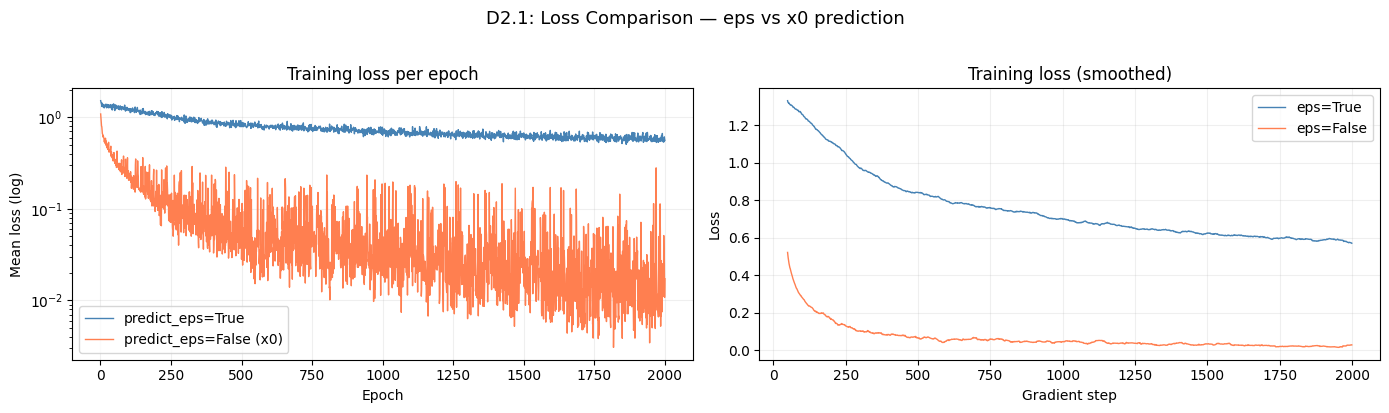


Final losses:
  predict_epsilon=True:  0.557225
  predict_epsilon=False: 0.017242


In [7]:
# --- Loss curves comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.semilogy(range(1, EPOCHS + 1), epoch_losses_eps, color="steelblue", linewidth=1.0, label="predict_eps=True")
ax.semilogy(range(1, EPOCHS + 1), epoch_losses_x0, color="coral", linewidth=1.0, label="predict_eps=False (x0)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean loss (log)")
ax.set_title("Training loss per epoch")
ax.legend()
ax.grid(alpha=0.2)

ax = axes[1]
window = min(50, max(1, len(losses_eps) // 20))
for losses, label, color in [(losses_eps, "eps=True", "steelblue"), (losses_x0, "eps=False", "coral")]:
    if window > 1:
        smoothed = np.convolve(losses, np.ones(window) / window, mode="valid")
        ax.plot(range(window - 1, len(losses)), smoothed, color=color, linewidth=1.0, label=label)
    else:
        ax.plot(losses, color=color, linewidth=0.5, label=label)
ax.set_xlabel("Gradient step")
ax.set_ylabel("Loss")
ax.set_title("Training loss (smoothed)")
ax.legend()
ax.grid(alpha=0.2)

fig.suptitle("D2.1: Loss Comparison — eps vs x0 prediction", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nFinal losses:")
print(f"  predict_epsilon=True:  {epoch_losses_eps[-1]:.6f}")
print(f"  predict_epsilon=False: {epoch_losses_x0[-1]:.6f}")

## Chunk Quality Comparison

Evaluate both models on the training data. Target: L2 < 1.0 (memorisation).

In [8]:
from src.latent_sope.eval.metrics import l2_chunk_error

test_batch = next(iter(dataloader))
test_batch_dev = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in test_batch.items()}

# Build ground truth x in the same way as the loss function
cat_sf = torch.cat([test_batch_dev["states_from"], test_batch_dev["actions_from"]], dim=-1)
cat_st = torch.cat([test_batch_dev["states_to"][:, :-1, :], test_batch_dev["actions_to"]], dim=-1)
x_gt = torch.cat([cat_sf, cat_st], dim=1)

print(f"Ground truth shape: {x_gt.shape}  (B={x_gt.shape[0]}, T={x_gt.shape[1]}, D={x_gt.shape[2]})")
print(f"Evaluating chunk reconstruction on {x_gt.shape[0]} training chunks...\n")

results = {}

for label, diffuser in [("eps=True", diffuser_eps), ("eps=False", diffuser_x0)]:
    cond = diffuser.make_cond(test_batch_dev)
    state_dim = diffuser.state_dim
    diffuser.diffusion.eval()

    with torch.no_grad():
        sample = diffuser.diffusion.conditional_sample(
            shape=x_gt.shape, cond=cond, guided=False, verbose=False,
        )
    x_hat = sample.trajectories

    x_gt_unnorm = diffuser.unnormalizer(x_gt).cpu().numpy()
    x_hat_unnorm = diffuser.unnormalizer(x_hat).cpu().numpy()

    err_s = l2_chunk_error(x_hat_unnorm[:, :, :state_dim], x_gt_unnorm[:, :, :state_dim])
    err_a = l2_chunk_error(x_hat_unnorm[:, :, state_dim:], x_gt_unnorm[:, :, state_dim:])

    results[label] = {
        "state_l2": err_s.mean_l2,
        "state_l2_std": err_s.std_l2,
        "action_l2": err_a.mean_l2,
        "action_l2_std": err_a.std_l2,
        "rmse_per_dim": err_s.rmse_per_dim,
        "x_hat_unnorm": x_hat_unnorm,
        "x_gt_unnorm": x_gt_unnorm,
    }
    print(f"[{label}] state L2 = {err_s.mean_l2:.4f} ± {err_s.std_l2:.4f}, "
          f"action L2 = {err_a.mean_l2:.4f} ± {err_a.std_l2:.4f}")

print(f"\n--- D2 baseline (dim_mults=(1,2), fs=2, cs=8): state L2 = 910.7 ---")
print(f"--- Target: state L2 < 1.0 ---")

# Pick the better model for downstream evaluation
best_label = min(results, key=lambda k: results[k]["state_l2"])
best_diffuser = diffuser_eps if best_label == "eps=True" else diffuser_x0
best_cfg = cfg_eps if best_label == "eps=True" else cfg_x0
print(f"\nBest model: {best_label} (state L2 = {results[best_label]['state_l2']:.4f})")

Ground truth shape: torch.Size([17, 8, 18])  (B=17, T=8, D=18)
Evaluating chunk reconstruction on 17 training chunks...


                                                                                                    
1 / 256 [                                                            ]   0% | 9.3 Hz
t : 255
                                                                                                    
                                                                                                    
2 / 256 [                                                            ]   0% | 17.4 Hz
t : 254


                                                                                                    
                                                                                                    
3 / 256 [                                                            ]   1% | 24.4 Hz
t : 253
                                                                                                    
                                                                                                    
4 / 256 [                                                            ]   1% | 30.8 Hz
t : 252
                                                                                                    
                                                                                                    
5 / 256 [#                                                           ]   1% | 36.6 Hz
t : 251
                                                                                                    
           

                                                                                                    
                                                                                                    
15 / 256 [###                                                         ]   5% | 73.8 Hz
t : 241
                                                                                                    
                                                                                                    
16 / 256 [###                                                         ]   6% | 76.1 Hz
t : 240
                                                                                                    
                                                                                                    
17 / 256 [###                                                         ]   6% | 78.5 Hz
t : 239
                                                                                                    
        

                                                                                                    
                                                                                                    
34 / 256 [#######                                                     ]  13% | 103.7 Hz
t : 222
                                                                                                    
                                                                                                    
35 / 256 [########                                                    ]  13% | 104.5 Hz
t : 221
                                                                                                    
                                                                                                    
36 / 256 [########                                                    ]  14% | 105.4 Hz
t : 220
                                                                                                    
     

                                                                                                    
                                                                                                    
46 / 256 [##########                                                  ]  17% | 112.2 Hz
t : 210
                                                                                                    
                                                                                                    
47 / 256 [###########                                                 ]  18% | 112.7 Hz
t : 209
                                                                                                    
                                                                                                    
48 / 256 [###########                                                 ]  18% | 113.3 Hz
t : 208
                                                                                                    
     

...

                                                                                                    
                                                                                                    
191 / 256 [############################################                ]  74% | 147.8 Hz
t : 65
                                                                                                    
                                                                                                    
192 / 256 [#############################################               ]  75% | 146.4 Hz
t : 64
                                                                                                    
                                                                                                    
193 / 256 [#############################################               ]  75% | 146.3 Hz
t : 63
                                                                                                    
     

                                                                                                    
                                                                                                    
210 / 256 [#################################################           ]  82% | 136.2 Hz
t : 46
                                                                                                    
                                                                                                    
211 / 256 [#################################################           ]  82% | 132.5 Hz
t : 45
                                                                                                    
                                                                                                    
212 / 256 [#################################################           ]  82% | 133.9 Hz
t : 44
                                                                                                    
     

                                                                                                    
                                                                                                    
220 / 256 [###################################################         ]  85% | 142.4 Hz
t : 36
                                                                                                    
                                                                                                    
221 / 256 [###################################################         ]  86% | 142.7 Hz
t : 35
                                                                                                    
                                                                                                    
222 / 256 [####################################################        ]  86% | 143.2 Hz
t : 34
                                                                                                    
     

                                                                                                    
                                                                                                    
242 / 256 [########################################################    ]  94% | 149.7 Hz
t : 14
                                                                                                    
                                                                                                    
243 / 256 [########################################################    ]  94% | 149.7 Hz
t : 13
                                                                                                    
                                                                                                    
244 / 256 [#########################################################   ]  95% | 149.9 Hz
t : 12
                                                                                                    
     

                                                                                                    
                                                                                                    
252 / 256 [########################################################### ]  98% | 150.9 Hz
t : 4
                                                                                                    
                                                                                                    
253 / 256 [########################################################### ]  98% | 150.8 Hz
t : 3
                                                                                                    
                                                                                                    
254 / 256 [########################################################### ]  99% | 150.7 Hz
t : 2
                                                                                                    
        

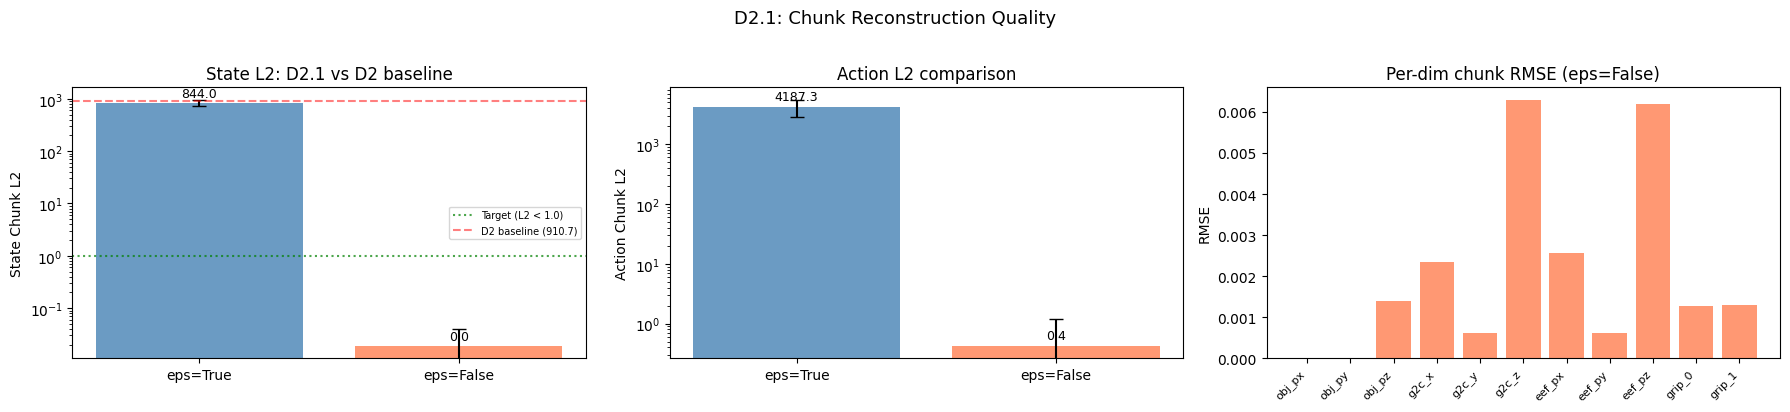


Best chunk L2: 0.0188 (eps=False)
PASS: Near-perfect memorisation! Architecture is sound.


In [9]:
# --- Chunk quality comparison plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Bar chart: state L2
ax = axes[0]
labels_list = list(results.keys())
state_l2s = [results[l]["state_l2"] for l in labels_list]
state_stds = [results[l]["state_l2_std"] for l in labels_list]
colors = ["steelblue", "coral"]
bars = ax.bar(labels_list, state_l2s, yerr=state_stds, color=colors, capsize=5, alpha=0.8)
ax.axhline(1.0, color="green", linestyle=":", alpha=0.7, label="Target (L2 < 1.0)")
ax.axhline(910.7, color="red", linestyle="--", alpha=0.5, label="D2 baseline (910.7)")
ax.set_ylabel("State Chunk L2")
ax.set_title("State L2: D2.1 vs D2 baseline")
ax.legend(fontsize=7)
ax.set_yscale("log")
for bar, val in zip(bars, state_l2s):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.3, f"{val:.1f}", ha="center", fontsize=9)

# Bar chart: action L2
ax = axes[1]
action_l2s = [results[l]["action_l2"] for l in labels_list]
action_stds = [results[l]["action_l2_std"] for l in labels_list]
bars = ax.bar(labels_list, action_l2s, yerr=action_stds, color=colors, capsize=5, alpha=0.8)
ax.set_ylabel("Action Chunk L2")
ax.set_title("Action L2 comparison")
ax.set_yscale("log")
for bar, val in zip(bars, action_l2s):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.3, f"{val:.1f}", ha="center", fontsize=9)

# Per-dim RMSE for best model
ax = axes[2]
best_rmse = results[best_label]["rmse_per_dim"]
ax.bar(range(len(best_rmse)), best_rmse, color=colors[0] if best_label == "eps=True" else colors[1], alpha=0.8)
ax.set_xticks(range(len(DIM_LABELS)))
ax.set_xticklabels(DIM_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("RMSE")
ax.set_title(f"Per-dim chunk RMSE ({best_label})")

fig.suptitle("D2.1: Chunk Reconstruction Quality", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Verdict
best_l2 = results[best_label]["state_l2"]
print(f"\nBest chunk L2: {best_l2:.4f} ({best_label})")
if best_l2 < 0.1:
    print("PASS: Near-perfect memorisation! Architecture is sound.")
elif best_l2 < 1.0:
    print("PASS: Model memorised the trajectory (L2 < 1.0).")
elif best_l2 < 100:
    print("PARTIAL: Significant improvement but not yet memorised.")
else:
    print("FAIL: Still cannot memorise. Further debugging needed.")

## Stitching with the Best Model

Generate a synthetic trajectory from the same initial state. Uses the best-performing model from above.

In [10]:
MAX_LENGTH = HORIZON
diffuser = best_diffuser
diffusion_config = best_cfg

# Use the real trajectory's initial state
traj = load_rollout_latents(rollout_paths[0])
latents = traj.latents
if latents.ndim == 3:
    latents = latents[:, 0, :]

init_state = torch.tensor(latents[0:1], dtype=torch.float32)  # (1, 11)
print(f"Using best model: {best_label}")
print(f"Initial state: {init_state.shape}")
print(f"Generating 1 stitched trajectory (max {MAX_LENGTH} steps)...\n")

syn_states, syn_actions, end_indices = diffuser.generate_full_trajectory(
    initial_states=init_state,
    max_length=MAX_LENGTH,
    guided=False,
    verbose=False,
)

print(f"Generated trajectory:")
print(f"  states shape: {syn_states.shape}")
print(f"  state range: [{syn_states.min():.4f}, {syn_states.max():.4f}]")
print(f"  action range: [{syn_actions.min():.4f}, {syn_actions.max():.4f}]")

# Real trajectory for comparison
real_T = latents.shape[0]
real_states = latents[:MAX_LENGTH][None, :, :]  # (1, T_real, 11)
real_actions = traj.actions[:MAX_LENGTH][None, :, :]  # (1, T_real, 7)

# Truncate both to the shorter length so shapes match
T_common = min(real_states.shape[1], syn_states.shape[1])
real_states = real_states[:, :T_common, :]
real_actions = real_actions[:, :T_common, :]
syn_states = syn_states[:, :T_common, :]
syn_actions = syn_actions[:, :T_common, :]
end_indices = np.minimum(end_indices, T_common)

print(f"\nReal trajectory:")
print(f"  original length: {real_T}, truncated to: {T_common}")
print(f"  state range: [{real_states.min():.4f}, {real_states.max():.4f}]")
print(f"  action range: [{real_actions.min():.4f}, {real_actions.max():.4f}]")

# Quick blowup check
blowup_ratio = max(abs(syn_states.min()), abs(syn_states.max())) / max(abs(real_states.min()), abs(real_states.max()), 1e-6)
print(f"\nBlowup ratio (syn max / real max): {blowup_ratio:.1f}x")
if blowup_ratio < 2.0:
    print("  -> Synthetic stays in distribution!")
elif blowup_ratio < 10.0:
    print("  -> Moderate blowup. Stitching drift is present but contained.")
else:
    print(f"  -> Significant blowup ({blowup_ratio:.0f}x). Stitching is amplifying errors.")

Using best model: eps=False
Initial state: torch.Size([1, 11])
Generating 1 stitched trajectory (max 60 steps)...




                                                                                                    
1 / 256 [                                                            ]   0% | 1.2 Hz
t : 255
                                                                                                    
                                                                                                    
2 / 256 [                                                            ]   0% | 2.5 Hz
t : 254
                                                                                                    
                                                                                                    
3 / 256 [                                                            ]   1% | 3.7 Hz
t : 253
                                                                                                    
                                                                                                    
4 / 256 [     

                                                                                                    
                                                                                                    
31 / 256 [#######                                                     ]  12% | 30.8 Hz
t : 225
                                                                                                    
                                                                                                    
32 / 256 [#######                                                     ]  12% | 31.6 Hz
t : 224
                                                                                                    
                                                                                                    
33 / 256 [#######                                                     ]  12% | 32.4 Hz
t : 223
                                                                                                    
        

                                                                                                    
                                                                                                    
62 / 256 [##############                                              ]  24% | 51.0 Hz
t : 194
                                                                                                    
                                                                                                    
63 / 256 [##############                                              ]  24% | 51.6 Hz
t : 193
                                                                                                    
                                                                                                    
64 / 256 [###############                                             ]  25% | 52.1 Hz
t : 192
                                                                                                    
        

                                                                                                    
                                                                                                    
93 / 256 [#####################                                       ]  36% | 65.6 Hz
t : 163
                                                                                                    
                                                                                                    
94 / 256 [######################                                      ]  36% | 66.0 Hz
t : 162
                                                                                                    
                                                                                                    
95 / 256 [######################                                      ]  37% | 66.4 Hz
t : 161
                                                                                                    
        

...

                                                                                                    
                                                                                                    
104 / 256 [########################                                    ]  40% | 142.3 Hz
t : 152
                                                                                                    
                                                                                                    
105 / 256 [########################                                    ]  41% | 141.4 Hz
t : 151
                                                                                                    
                                                                                                    
106 / 256 [########################                                    ]  41% | 142.5 Hz
t : 150
                                                                                                    
  

                                                                                                    
                                                                                                    
135 / 256 [###############################                             ]  52% | 148.9 Hz
t : 121
                                                                                                    
                                                                                                    
136 / 256 [###############################                             ]  53% | 148.7 Hz
t : 120
                                                                                                    
                                                                                                    
137 / 256 [################################                            ]  53% | 148.8 Hz
t : 119
                                                                                                    
  

                                                                                                    
                                                                                                    
166 / 256 [######################################                      ]  64% | 149.0 Hz
t : 90
                                                                                                    
                                                                                                    
167 / 256 [#######################################                     ]  65% | 148.9 Hz
t : 89
                                                                                                    
                                                                                                    
168 / 256 [#######################################                     ]  65% | 148.9 Hz
t : 88
                                                                                                    
     

                                                                                                    
                                                                                                    
197 / 256 [##############################################              ]  76% | 149.0 Hz
t : 59
                                                                                                    
                                                                                                    
198 / 256 [##############################################              ]  77% | 149.0 Hz
t : 58
                                                                                                    
                                                                                                    
199 / 256 [##############################################              ]  77% | 149.0 Hz
t : 57
                                                                                                    
     

                                                                                                    
                                                                                                    
228 / 256 [#####################################################       ]  89% | 150.9 Hz
t : 28
                                                                                                    
                                                                                                    
229 / 256 [#####################################################       ]  89% | 150.4 Hz
t : 27
                                                                                                    
                                                                                                    
230 / 256 [#####################################################       ]  89% | 150.3 Hz
t : 26
                                                                                                    
     

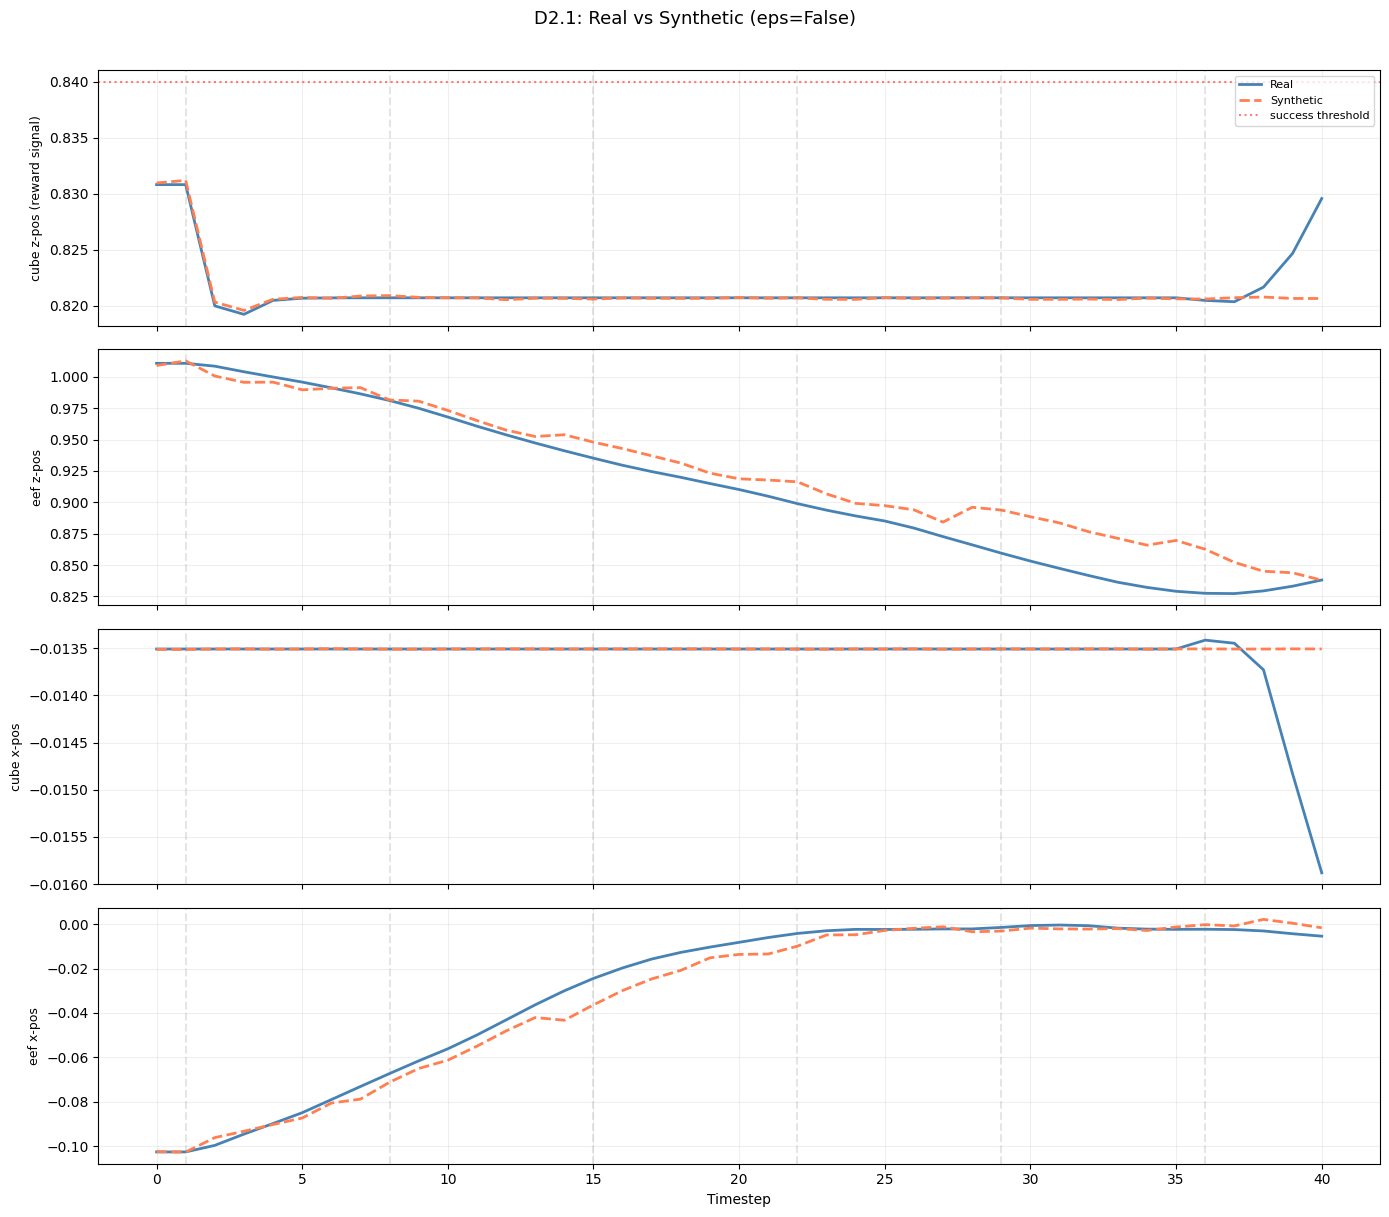

In [11]:
# --- Visual: real vs synthetic trajectory ---
chunk_size = diffusion_config.chunk_horizon
frame_stack = diffusion_config.frame_stack

key_dims = [
    (CUBE_Z_IDX, "cube z-pos (reward signal)"),
    (EEF_Z_IDX, "eef z-pos"),
    (CUBE_X_IDX, "cube x-pos"),
    (EEF_X_IDX, "eef x-pos"),
]

fig, axes = plt.subplots(len(key_dims), 1, figsize=(14, 3 * len(key_dims)), sharex=True)
for row, (dim_idx, dim_name) in enumerate(key_dims):
    ax = axes[row]
    ax.plot(real_states[0, :, dim_idx], color="steelblue", linewidth=2, label="Real")
    ax.plot(syn_states[0, :, dim_idx], color="coral", linewidth=2, linestyle="--", label="Synthetic")
    ax.set_ylabel(dim_name, fontsize=9)
    if dim_idx == CUBE_Z_IDX:
        ax.axhline(SUCCESS_THRESHOLD, color="red", linestyle=":", alpha=0.5, label="success threshold")
    # Mark chunk boundaries
    for boundary in range(frame_stack, T_common, chunk_size):
        ax.axvline(boundary, color="gray", alpha=0.2, linestyle="--")
    ax.grid(alpha=0.2)
    if row == 0:
        ax.legend(fontsize=8)

axes[-1].set_xlabel("Timestep")
fig.suptitle(f"D2.1: Real vs Synthetic ({best_label})", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

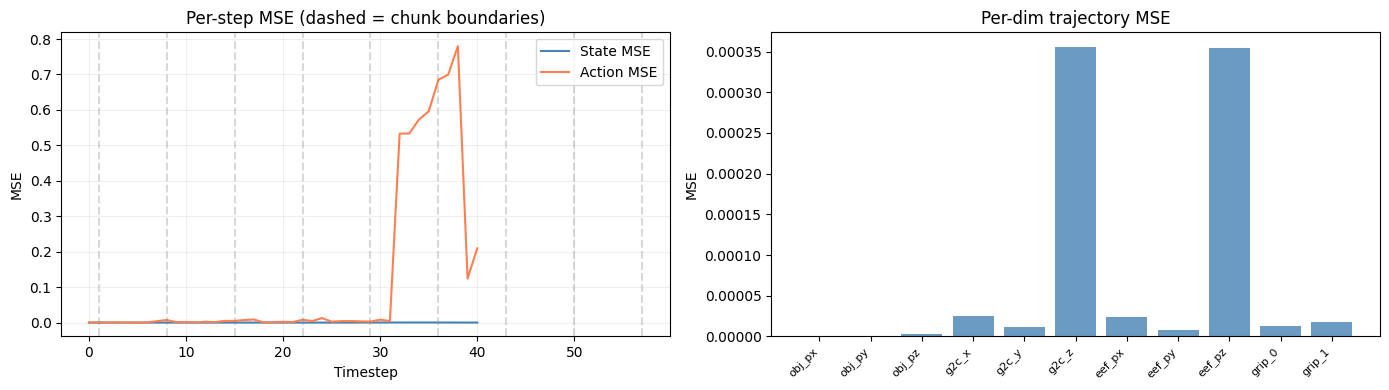

Trajectory State MSE:  0.000074
Trajectory Action MSE: 0.118059

Dim         Real mean   Syn mean   Real std    Syn std       Real [min,max]        Syn [min,max]
------------------------------------------------------------------------------------------------------
obj_px        -0.0136    -0.0135     0.0004     0.0000 [ -0.016,  -0.013]  [ -0.014,  -0.014]
obj_py         0.0005     0.0003     0.0008     0.0000 [  0.000,   0.004]  [  0.000,   0.000]
obj_pz         0.8214     0.8211     0.0026     0.0023 [  0.819,   0.831]  [  0.820,   0.831]
g2c_x          0.0160     0.0182     0.0352     0.0349 [ -0.013,   0.089]  [ -0.014,   0.088]
g2c_y         -0.0074    -0.0085     0.0033     0.0014 [ -0.011,   0.003]  [ -0.011,  -0.006]
g2c_z         -0.0910    -0.1051     0.0615     0.0515 [ -0.188,  -0.007]  [ -0.185,  -0.016]
eef_px        -0.0296    -0.0321     0.0352     0.0354 [ -0.103,  -0.000]  [ -0.103,   0.002]
eef_py         0.0079     0.0088     0.0026     0.0014 [ -0.000,   0.012]  [ 

In [12]:
# --- Per-step MSE ---
from src.latent_sope.eval.metrics import trajectory_reconstruction_mse

recon = trajectory_reconstruction_mse(
    real_states.astype(np.float32), syn_states,
    real_actions.astype(np.float32), syn_actions,
    end_indices,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(recon.state_mse_per_step, color="steelblue", linewidth=1.5, label="State MSE")
ax.plot(recon.action_mse_per_step, color="coral", linewidth=1.5, label="Action MSE")
for boundary in range(frame_stack, MAX_LENGTH, chunk_size):
    ax.axvline(boundary, color="gray", alpha=0.3, linestyle="--")
ax.set_xlabel("Timestep")
ax.set_ylabel("MSE")
ax.set_title("Per-step MSE (dashed = chunk boundaries)")
ax.legend()
ax.grid(alpha=0.2)

ax = axes[1]
ax.bar(range(len(recon.state_mse_per_dim)), recon.state_mse_per_dim, color="steelblue", alpha=0.8)
ax.set_xticks(range(len(DIM_LABELS)))
ax.set_xticklabels(DIM_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("MSE")
ax.set_title("Per-dim trajectory MSE")

plt.tight_layout()
plt.show()

print(f"Trajectory State MSE:  {recon.state_mse:.6f}")
print(f"Trajectory Action MSE: {recon.action_mse:.6f}")

# Marginal statistics
print(f"\n{'Dim':<10} {'Real mean':>10} {'Syn mean':>10} {'Real std':>10} {'Syn std':>10} {'Real [min,max]':>20} {'Syn [min,max]':>20}")
print("-" * 102)
for d, label in enumerate(DIM_LABELS):
    r, s = real_states[0, :, d], syn_states[0, :, d]
    print(f"{label:<10} {r.mean():10.4f} {s.mean():10.4f} {r.std():10.4f} {s.std():10.4f} "
          f"[{r.min():7.3f}, {r.max():7.3f}]  [{s.min():7.3f}, {s.max():7.3f}]")

## OPE on Memorized Trajectory

In [13]:
from src.latent_sope.eval.metrics import ope_eval

# Compute returns directly from cube z
syn_cube_z = syn_states[:, :, CUBE_Z_IDX]
syn_rewards = (syn_cube_z > SUCCESS_THRESHOLD).astype(np.float32)
syn_returns = syn_rewards.sum(axis=1)

real_cube_z = real_states[:, :, CUBE_Z_IDX]
real_rewards_traj = (real_cube_z > SUCCESS_THRESHOLD).astype(np.float32)
real_returns = real_rewards_traj.sum(axis=1)

ope_result = ope_eval(oracle_value, syn_returns)

best_l2 = results[best_label]["state_l2"]

print("=" * 60)
print("D2.1: Overfit 1 Trajectory — Summary")
print("=" * 60)
print(f"  Best model:           {best_label}")
print(f"  Oracle V^pi:          {oracle_value:.3f}")
print(f"  Real traj return:     {real_returns[0]:.1f}")
print(f"  Synthetic return:     {syn_returns[0]:.1f}")
print(f"  OPE estimate:         {ope_result.ope_estimate:.3f}")
print(f"  Relative error:       {ope_result.relative_error:.2%}")
print(f"  Final chunk L2:       {best_l2:.4f}")
print(f"  State MSE:            {recon.state_mse:.4f}")
print(f"  Blowup ratio:         {blowup_ratio:.1f}x")
print("=" * 60)
print(f"\n--- Comparison to D2 ---")
print(f"  D2 chunk L2:   910.7  →  D2.1: {best_l2:.1f}  ({910.7/max(best_l2,1e-6):.1f}x improvement)")
print(f"  D2 blowup:     816.1x →  D2.1: {blowup_ratio:.1f}x")
print(f"  D2 state MSE:  19,423 →  D2.1: {recon.state_mse:.1f}")

# Separate results
print(f"\n--- eps=True vs eps=False ---")
for label in results:
    r = results[label]
    print(f"  [{label}] state L2={r['state_l2']:.4f}, action L2={r['action_l2']:.4f}")

print(f"\n--- Verdict ---")
if best_l2 < 0.1 and blowup_ratio < 2.0:
    print("PASS: Model memorized chunks AND stitching works.")
    print("  -> Architecture is correct. Next: scale to 50+ rollouts.")
elif best_l2 < 0.1 and blowup_ratio >= 2.0:
    print("PARTIAL PASS: Chunks memorized but stitching drifts.")
    print("  -> Chunk generation works. Stitching needs fixes (overlap, clamping).")
elif best_l2 < 1.0:
    print("PASS: Model memorised the trajectory (L2 < 1.0).")
    print("  -> Next: scale to 50+ rollouts with this config.")
elif best_l2 < 100:
    print("PARTIAL: Significant improvement but not full memorisation.")
    print("  -> More epochs or further tuning needed.")
else:
    print("FAIL: Cannot memorize 1 trajectory.")
    print("  -> Debug: check loss function, conditioning, model architecture.")

D2.1: Overfit 1 Trajectory — Summary
  Best model:           eps=False
  Oracle V^pi:          0.540
  Real traj return:     0.0
  Synthetic return:     0.0
  OPE estimate:         0.000
  Relative error:       100.00%
  Final chunk L2:       0.0188
  State MSE:            0.0001
  Blowup ratio:         1.0x

--- Comparison to D2 ---
  D2 chunk L2:   910.7  →  D2.1: 0.0  (48375.9x improvement)
  D2 blowup:     816.1x →  D2.1: 1.0x
  D2 state MSE:  19,423 →  D2.1: 0.0

--- eps=True vs eps=False ---
  [eps=True] state L2=843.9984, action L2=4187.3071
  [eps=False] state L2=0.0188, action L2=0.4224

--- Verdict ---
PASS: Model memorized chunks AND stitching works.
  -> Architecture is correct. Next: scale to 50+ rollouts.


## Conclusions

**Changes from D2:**
- dim_mults: (1,2) → (1,4,8) — ~10x more parameters
- frame_stack: 2 → 1 — match SOPE
- chunk_size: 8 → 7 — total_horizon=8, divisible by 4
- Fixed sample() off-by-one in sope_diffuser.py
- Tested both predict_epsilon=True and False

**Results will be logged to:** `results/2026-03-10/D2.1_memorisation_fixes.md`